In [19]:
import pandas as pd

file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\fatality rate_variables_GTD.xlsx"

# Read both sheets
nkill_df = pd.read_excel(file_path, sheet_name="nkill")
nwound_df = pd.read_excel(file_path, sheet_name="nwound")



In [20]:
# Convert nkill
nkill_long = nkill_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nkill"
)

# Convert nwound
nwound_long = nwound_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nwound"
)

In [21]:
panel_df = pd.merge(
    nkill_long,
    nwound_long,
    on=["Country", "Year"],
    how="inner"
)

In [22]:
panel_df["Year"] = panel_df["Year"].astype(int)
panel_df = panel_df.sort_values(by=["Country", "Year"])

In [23]:
# Avoid division by zero
panel_df["fatality_rate"] = panel_df["nkill"] / (panel_df["nkill"] + panel_df["nwound"])

# Handle cases where nkill + nwound = 0
panel_df["fatality_rate"] = panel_df["fatality_rate"].fillna(0)

In [24]:

panel_df

,Country,Year,nkill,nwound,fatality_rate
0,Afghanistan,1970,NaN,NaN,0.000000
204,Afghanistan,1971,NaN,NaN,0.000000
408,Afghanistan,1972,NaN,NaN,0.000000
612,Afghanistan,1973,0.0,1.0,0.000000
816,Afghanistan,1974,NaN,NaN,0.000000
...,...,...,...,...,...
9383,Zimbabwe,2016,NaN,NaN,0.000000
9587,Zimbabwe,2017,0.0,1.0,0.000000
9791,Zimbabwe,2018,2.0,47.0,0.040816
9995,Zimbabwe,2019,0.0,0.0,0.000000


In [25]:
import pandas as pd
from functools import reduce

file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\WGI_fatality_1.xlsx"

xls = pd.ExcelFile(file_path)
dfs = []

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    # Rename 'value' to indicator name (sheet name)
    df.rename(columns={"value": sheet.lower()}, inplace=True)
    
    # Keep required columns
    df = df[["Country", "Year", sheet.lower()]]
    
    # Clean data
    df["Country"] = df["Country"].str.strip().str.lower()
    df["Year"] = df["Year"].astype(int)
    
    # Ensure uniqueness (VERY IMPORTANT)
    df = df.drop_duplicates(subset=["Country", "Year"])
    
    dfs.append(df)

# Merge all sheets
wgi_merged = reduce(
    lambda left, right: pd.merge(left, right, on=["Country", "Year"], how="inner"),
    dfs
)

# Sort
wgi_merged = wgi_merged.sort_values(by=["Country", "Year"]).reset_index(drop=True)

# Check
print(wgi_merged.shape)
print(wgi_merged.head())

(4973, 8)
       Country  Year  voice and accountability  political stability  \
0  afghanistan  1996                    0.0625               0.0625   
1  afghanistan  1998                    0.0625               0.0625   
2  afghanistan  2000                    0.0625               0.0625   
3  afghanistan  2002                    0.1875               0.0625   
4  afghanistan  2003                    0.2500               0.1250   

   government effectiveness  regulatory quality  rule of law  \
0                     0.000            0.000000       0.1875   
1                     0.000            0.000000       0.1875   
2                     0.000            0.000000       0.1875   
3                     0.125            0.166667       0.1875   
4                     0.125            0.250000       0.1875   

   control of corruption  
0                  0.000  
1                  0.000  
2                  0.000  
3                  0.125  
4                  0.125  


In [26]:
# Ensure same format before merging

# Clean panel_df (terrorism data)
panel_df["Country"] = panel_df["Country"].astype(str).str.strip().str.lower()
panel_df["Year"] = panel_df["Year"].astype(int)

# Clean WGI data
wgi_merged["Country"] = wgi_merged["Country"].astype(str).str.strip().str.lower()
wgi_merged["Year"] = wgi_merged["Year"].astype(int)

# Merge
final_df = pd.merge(
    panel_df,
    wgi_merged,
    on=["Country", "Year"],
    how="left"   # 🔥 recommended
)

In [42]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': final_df.isna().sum(),
    'Zero_Count': (final_df == 0).sum(),
    'Total_Values': final_df.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                          NaN_Count  Zero_Count  Total_Values      NaN_%  \
Country                           0           0         10200   0.000000   
Year                              0           0         10200   0.000000   
nkill                          6179        1247         10200  60.578431   
nwound                         6212        1199         10200  60.901961   
fatality_rate                     0        7459         10200   0.000000   
voice and accountability       6897          95         10200  67.617647   
political stability            6897          42         10200  67.617647   
government effectiveness       6897         667         10200  67.617647   
regulatory quality             6897          20         10200  67.617647   
rule of law                    6897           0         10200  67.617647   
control of corruption          6897         519         10200  67.617647   

                             Zero_%  
Country                    0.000000  
Year       

In [28]:
df=final_df.copy()
df

,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption
0,afghanistan,1970,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,afghanistan,1971,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,afghanistan,1972,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,afghanistan,1973,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,afghanistan,1974,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10195,zimbabwe,2016,NaN,NaN,0.000000,0.185000,0.3125,0.0,0.107143,0.125,0.0
10196,zimbabwe,2017,0.0,1.0,0.000000,0.188667,0.3125,0.0,0.107143,0.100,0.0
10197,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.0,0.107143,0.150,0.0
10198,zimbabwe,2019,0.0,0.0,0.000000,0.105333,0.1250,0.0,0.107143,0.125,0.0


In [ ]:
#Basic cleaning
cols = ['fatality_rate', 'voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=cols)

# Log transform (important)
import numpy as np
df['log_fatality_rate'] = np.log1p(df['fatality_rate'])

df

C:\Users\DELL\AppData\Local\Temp\ipykernel_50192\4032132893.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')


,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate
25,afghanistan,1996,31.0,30.0,0.508197,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.410915
27,afghanistan,1998,8.0,30.0,0.210526,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.191055
29,afghanistan,2000,38.0,11.0,0.775510,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.574088
31,afghanistan,2002,74.0,297.0,0.199461,0.187500,0.0625,0.125,0.166667,0.1875,0.125,0.181872
32,afghanistan,2003,163.0,186.0,0.467049,0.250000,0.1250,0.125,0.250000,0.1875,0.125,0.383253
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,zimbabwe,2016,NaN,NaN,0.000000,0.185000,0.3125,0.000,0.107143,0.1250,0.000,0.000000
10196,zimbabwe,2017,0.0,1.0,0.000000,0.188667,0.3125,0.000,0.107143,0.1000,0.000,0.000000
10197,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.000,0.107143,0.1500,0.000,0.040005
10198,zimbabwe,2019,0.0,0.0,0.000000,0.105333,0.1250,0.000,0.107143,0.1250,0.000,0.000000


DESCRIPTIVE ANALYSIS

In [43]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': df.isna().sum(),
    'Zero_Count': (df == 0).sum(),
    'Total_Values': df.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                          NaN_Count  Zero_Count  Total_Values      NaN_%  \
Country                           0           0          3303   0.000000   
Year                              0           0          3303   0.000000   
nkill                          1737         499          3303  52.588556   
nwound                         1754         409          3303  53.103239   
fatality_rate                     0        2250          3303   0.000000   
voice and accountability          0          95          3303   0.000000   
political stability               0          42          3303   0.000000   
government effectiveness          0         667          3303   0.000000   
regulatory quality                0          20          3303   0.000000   
rule of law                       0           0          3303   0.000000   
control of corruption             0         519          3303   0.000000   
log_fatality_rate                 0        2250          3303   0.000000   
governance_i

In [40]:
df[cols + ['log_fatality_rate']].describe()

,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate
count,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000
mean,0.150806,0.484401,0.586630,0.390772,0.511076,0.506985,0.368951,0.117803
std,0.271987,0.266143,0.248905,0.297224,0.231398,0.246907,0.277941,0.202222
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.025000,0.000000,0.000000
25%,0.000000,0.264500,0.437500,0.250000,0.357143,0.325000,0.125000,0.000000
50%,0.000000,0.469333,0.565657,0.250000,0.500000,0.475000,0.250000,0.000000
75%,0.225978,0.723167,0.812500,0.500000,0.714286,0.700000,0.500000,0.203738
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.693147


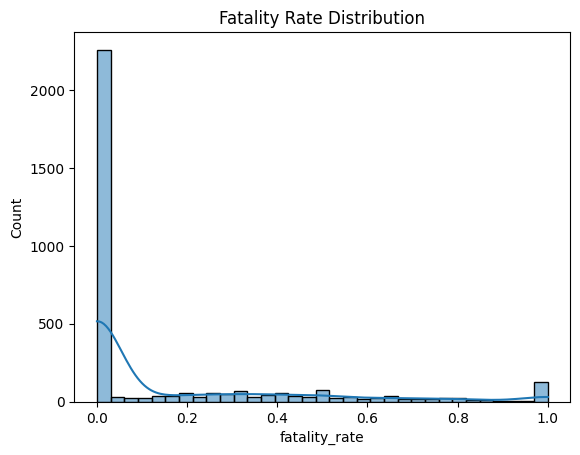

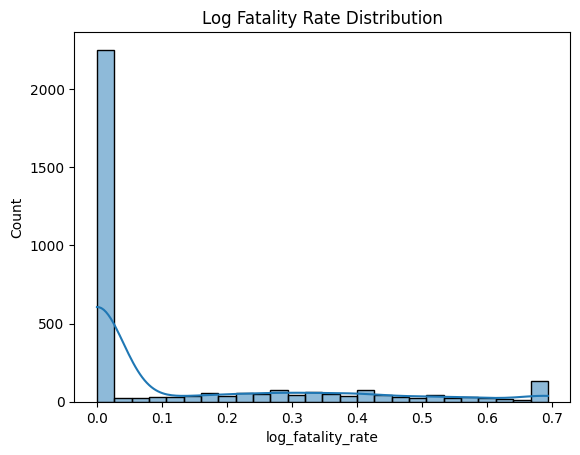

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['fatality_rate'], kde=True)
plt.title("Fatality Rate Distribution")
plt.show()

sns.histplot(df['log_fatality_rate'], kde=True)
plt.title("Log Fatality Rate Distribution")
plt.show()

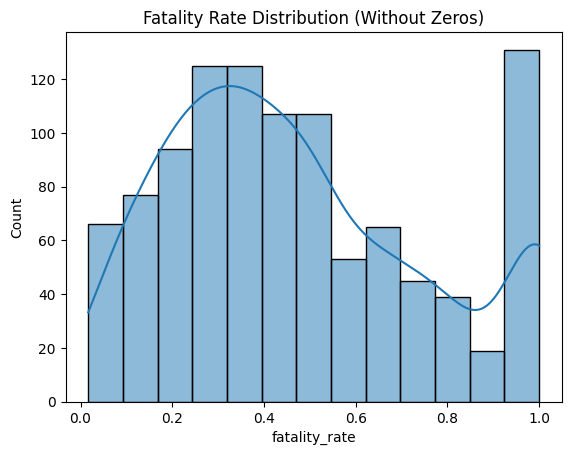

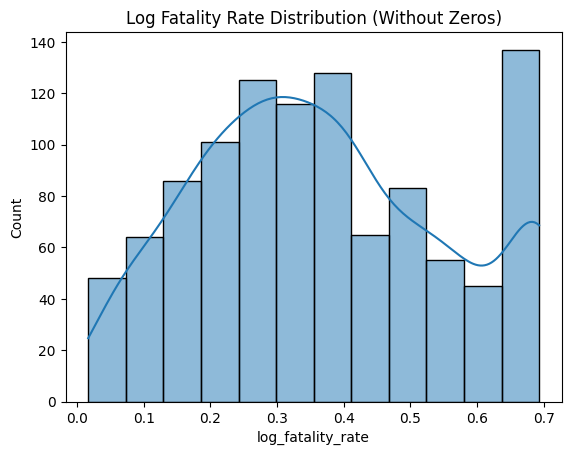

In [44]:
df_no_zero = df[df['fatality_rate'] > 0]

import seaborn as sns
import matplotlib.pyplot as plt

# Fatality Rate (no zeros)
sns.histplot(df_no_zero['fatality_rate'], kde=True)
plt.title("Fatality Rate Distribution (Without Zeros)")
plt.show()

# Log Fatality Rate (no zeros)
sns.histplot(df_no_zero['log_fatality_rate'], kde=True)
plt.title("Log Fatality Rate Distribution (Without Zeros)")
plt.show()

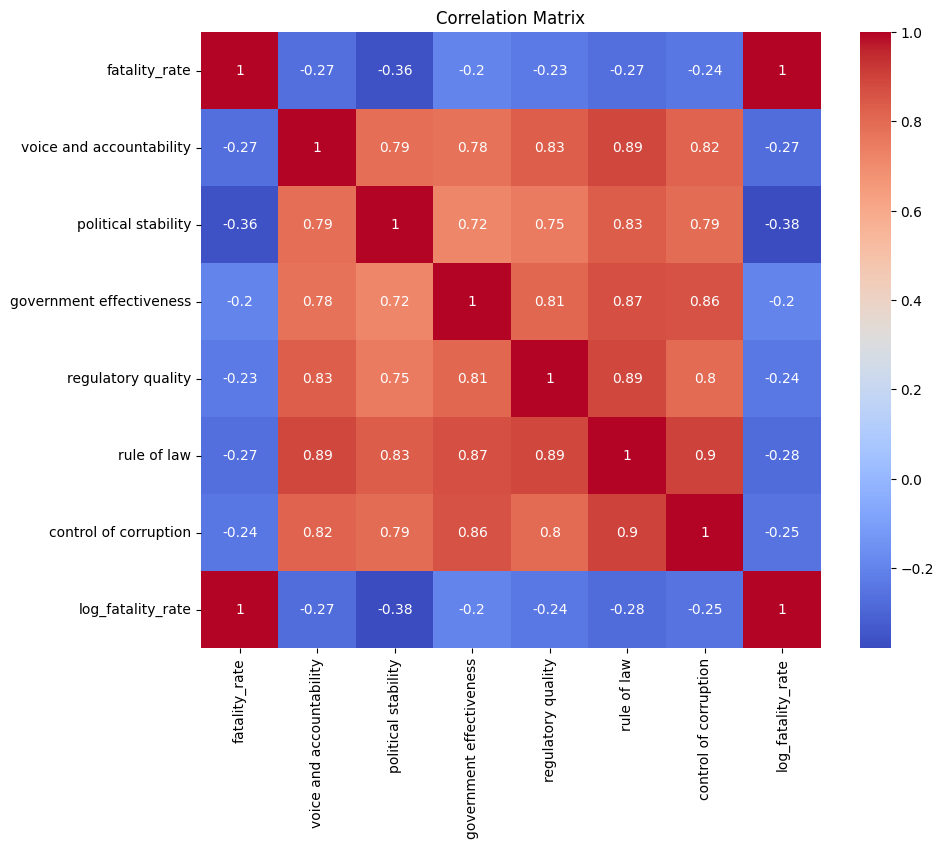

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(df[cols + ['log_fatality_rate']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

<Axes: >

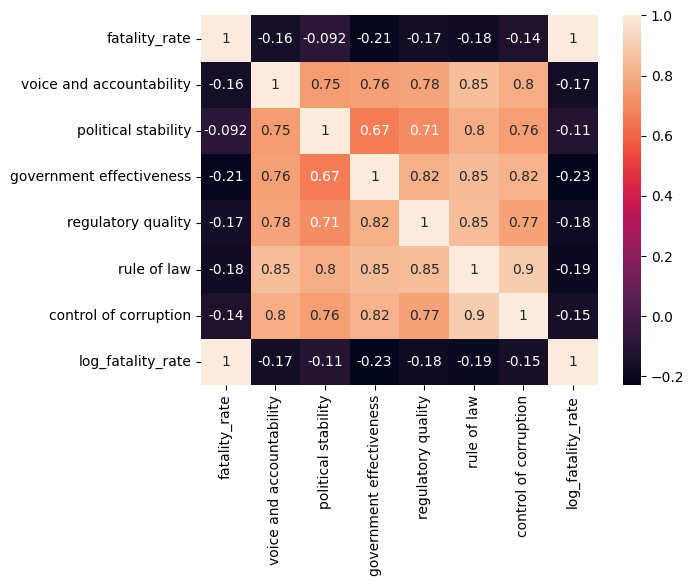

In [46]:
import seaborn as sns
sns.heatmap(df_no_zero[cols + ['log_fatality_rate']].corr(), annot=True)

INFERENTIAL ANALYSIS

In [ ]:
#Normality Test
from scipy.stats import shapiro

shapiro(df['log_fatality_rate'])

ShapiroResult(statistic=np.float64(0.6391529112439116), pvalue=np.float64(4.189406893000716e-64))

In [49]:
#Group Comparison (optional but strong)
df['governance_index'] = df[
    ['voice and accountability', 'political stability',
     'government effectiveness', 'regulatory quality',
     'rule of law', 'control of corruption']
].mean(axis=1)

df['gov_group'] = pd.qcut(df['governance_index'], 3, labels=['Low','Medium','High'])

#ANOVA
from scipy.stats import f_oneway

groups = [g['log_fatality_rate'].values for _, g in df.groupby('gov_group')]
f_oneway(*groups)

C:\Users\DELL\AppData\Local\Temp\ipykernel_50192\2940020813.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g['log_fatality_rate'].values for _, g in df.groupby('gov_group')]


F_onewayResult(statistic=np.float64(170.91696184181203), pvalue=np.float64(2.3430128629883435e-71))

In [50]:
#non parametric
from scipy.stats import kruskal
kruskal(*groups)

KruskalResult(statistic=np.float64(325.26217237685813), pvalue=np.float64(2.345398712618144e-71))

REGRESSION ANALYSIS

In [51]:
#OLS regression
import statsmodels.api as sm

X = df[['voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']]

X = sm.add_constant(X)
y = df['log_fatality_rate']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     100.9
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          6.97e-117
Time:                        08:20:47   Log-Likelihood:                 871.68
No. Observations:                3303   AIC:                            -1729.
Df Residuals:                    3296   BIC:                            -1687.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [52]:
#Multicollienarity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                    feature        VIF
0                     const   9.592787
1  voice and accountability   5.173072
2       political stability   3.527381
3  government effectiveness   4.930513
4        regulatory quality   5.161143
5               rule of law  12.410314
6     control of corruption   6.577889


In [54]:
#PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = df[['voice and accountability', 'political stability',
               'government effectiveness', 'regulatory quality',
               'rule of law', 'control of corruption']]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=1)
df['governance_pca'] = pca.fit_transform(scaled)

X_pca = sm.add_constant(df['governance_pca'])
model_pca = sm.OLS(y, X_pca).fit()
print(model_pca.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     306.8
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           9.29e-66
Time:                        08:21:57   Log-Likelihood:                 740.01
No. Observations:                3303   AIC:                            -1476.
Df Residuals:                    3301   BIC:                            -1464.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1178      0.003     34.

PANEL DATA ANALYSIS (VERY IMPORTANT 🔥)

In [55]:
#Fixed Effects Model
from linearmodels.panel import PanelOLS

df = df.set_index(['Country', 'Year'])

X = df[['governance_pca']]
y = df['log_fatality_rate']

model_fe = PanelOLS(y, X, entity_effects=True)
fe_res = model_fe.fit()
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:      log_fatality_rate   R-squared:                        0.0012
Estimator:                   PanelOLS   R-squared (Between):              0.0704
No. Observations:                3303   R-squared (Within):               0.0012
Date:                Thu, Mar 26 2026   R-squared (Overall):              0.0386
Time:                        08:23:08   Log-likelihood                    1354.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      3.8407
Entities:                         156   P-value                           0.0501
Avg Obs:                       21.173   Distribution:                  F(1,3146)
Min Obs:                       3.0000                                           
Max Obs:                       22.000   F-statistic (robust):             3.8407
                            

In [56]:
#Random Effects Model
from linearmodels.panel import RandomEffects

model_re = RandomEffects(y, X)
re_res = model_re.fit()
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:      log_fatality_rate   R-squared:                        0.0059
Estimator:              RandomEffects   R-squared (Between):              0.1022
No. Observations:                3303   R-squared (Within):               0.0006
Date:                Thu, Mar 26 2026   R-squared (Overall):              0.0555
Time:                        08:23:34   Log-likelihood                    1273.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      19.649
Entities:                         156   P-value                           0.0000
Avg Obs:                       21.173   Distribution:                  F(1,3302)
Min Obs:                       3.0000                                           
Max Obs:                       22.000   F-statistic (robust):             19.649
                            

In [57]:
#Hausman Test
from linearmodels.panel import compare

compare({'FE': fe_res, 'RE': re_res})

,FE,RE
Dep. Variable,log_fatality_rate,log_fatality_rate
Estimator,PanelOLS,RandomEffects
No. Observations,3303,3303
Cov. Est.,Unadjusted,Unadjusted
R-squared,0.0012,0.0059
R-Squared (Within),0.0012,0.0006
R-Squared (Between),0.0704,0.1022
R-Squared (Overall),0.0386,0.0555
F-statistic,3.8407,19.649
P-value (F-stat),0.0501,0.0000


ROBUSTNESS CHECKS

In [58]:
#Heteroskedasticity
from statsmodels.stats.diagnostic import het_breuschpagan

het_breuschpagan(model.resid, X)

ValueError: The Breusch-Pagan test requires exog to have at least two columns where one is a constant.